# Feature Engineering and Scaling

TODO: add introduction

## Environment and Model Loading

In [1]:
# Set to True only if you need to re-train the 128-dim Word2Vec on the 1.4M corpus
TRAIN_MARATHON_W2V = True

import sys
from pathlib import Path
p = Path.cwd().resolve()
while p != p.parent and not (p / "src").exists():
    p = p.parent
if str(p) not in sys.path:
    sys.path.insert(0, str(p))

import json
import time
from datetime import datetime

from src.config import load_settings
from src.spark.session import get_spark

from src.spark.features.build_features import build_features_with_full_corpus_w2v
from src.spark.labeling.taxonomy import get_tag_ids
from src.spark.features.pipeline import TextFeatureSpec, add_token_union_column
from src.spark.features.embeddings import add_word2vec_embeddings, Word2VecSpec
from src.spark.features.labels import add_binary_label_cols
from src.spark.labeling.taxonomy import get_tag_ids
from src.spark.features.prototypes import PrototypeSpec, build_tag_centroids
from src.spark.modeling.inference import _native_cosine_sim
from src.spark.features.splits import assign_recipe_splits

from pyspark.ml.functions import vector_to_array
from pyspark.ml.pipeline import PipelineModel
from pyspark.ml.feature import Word2VecModel
import pyspark.sql.functions as F
from pyspark.sql.types import ArrayType

s = load_settings(prefer_latest_run=True)
spark = get_spark(app_name="02_feature_engineering_scaleout", debug=True)
spark.conf.set("spark.hadoop.mapreduce.fileoutputcommitter.algorithm.version", "2")



your 131072x1 screen size is bogus. expect trouble
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/03 11:32:01 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [2]:
if TRAIN_MARATHON_W2V:
    print(f"STARTING MARATHON RUN: Training Word2Vec on 1.4M reviews...")
    start_time = time.time()
    
    spark.catalog.clearCache()
    spark.conf.set("spark.sql.sources.partitionOverwriteMode", "dynamic")
    
    # Define the label path
    # Adjust as needed to point to the correct version of the labeled data
    current_labeled_data = str(Path(s.processed_dir) / "labeling" / "zero_shot" / "labeled_gold_reviews_v5.parquet")
    
    # Trigger the Build
    build_features_with_full_corpus_w2v(
        spark=spark, 
        labels=get_tag_ids(), 
        labeled_data_path=current_labeled_data
    )
    
    elapsed = (time.time() - start_time) / 60
    print(f"Build Successful! Total Time: {elapsed:.2f} minutes")

    # Refresh Settings to grab the ID the function just created
    s = load_settings(prefer_latest_run=True)
    
    # Load the fresh models
    prep_model = PipelineModel.load(f"{s.features_pipeline_model_dir}/prep_model")
    w2v_model = Word2VecModel.load(f"{s.features_pipeline_model_dir}/w2v_model")
    
    print(f"Context Switched to New Run: {s.features_run_id}")
    print(f"Ready to compare against Legacy: {s.previous_run_id}")

else:
    print(f"Skipping Training. Loading existing models from: {s.features_run_id}")
    prep_model = PipelineModel.load(f"{s.features_pipeline_model_dir}/prep_model")
    w2v_model = Word2VecModel.load(f"{s.features_pipeline_model_dir}/w2v_model")

STARTING MARATHON RUN: Training Word2Vec on 1.4M reviews...


26/03/03 11:33:23 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.VectorBLAS
26/03/03 15:22:15 WARN TaskSetManager: Stage 71 contains a task of very large size (33477 KiB). The maximum recommended task size is 1000 KiB.
26/03/03 15:22:26 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


Build Successful! Total Time: 230.56 minutes


Context Switched to New Run: 20260303_113202
Ready to compare against Legacy: 20260302_212458


In [ ]:
# Load v5 Ground Truth 
current_labeled_data = str(Path(s.processed_dir) / "labeling" / "zero_shot" / "labeled_gold_reviews_v5.parquet")
labeled_df = spark.read.parquet(current_labeled_data)

# Assign splits (train/val/test) at the recipe level to prevent data leakage
labeled_df = assign_recipe_splits(labeled_df, recipe_id_col="recipe_id")

s = load_settings(prefer_latest_run=True)
w2v_model = Word2VecModel.load(f"{s.features_pipeline_model_dir}/w2v_model")
spec = TextFeatureSpec(text_col="review_clean", output_col="features", token_union_col="tokens_all")
w2v_spec = Word2VecSpec(input_col="tokens_all", output_col="review_embeddings")

# RE-TRANSFORM your labeled data with the NEW model
df_prep = add_token_union_column(prep_model.transform(labeled_df), spec)
df_embed = add_word2vec_embeddings(df_prep, model=w2v_model, spec=w2v_spec)

# CRITICAL: Rename to 'features' BEFORE building centroids
df_embed = df_embed.withColumn("features", F.col("review_embeddings"))

# Finalize binary columns (y_too_salty, etc)
labels = get_tag_ids()
df_embed = add_binary_label_cols(df_embed, labels)

In [11]:
# Force-delete the current run's centroids from disk to ensure no ghosting
import shutil
if Path(s.features_tag_centroids_path).exists():
    shutil.rmtree(s.features_tag_centroids_path)

# Re-run the centroid calculation in the notebook
p_spec = PrototypeSpec(features_col="features", label_prefix="y_", split_col="split")
centroids_df = build_tag_centroids(df_embed, spec=p_spec, labels=labels)
centroids_df.write.mode("overwrite").parquet(s.features_tag_centroids_path)

In [12]:
from src.spark.features.thresholds import calculate_diagonal_thresholds

# Build new Centroids
p_spec = PrototypeSpec(features_col="features", label_prefix="y_", split_col="split")
centroids_df = build_tag_centroids(df_embed, spec=p_spec, labels=labels)

# Save new Centroids
centroids_df.write.mode("overwrite").parquet(s.features_tag_centroids_path)

# Block 3.1: Finalized Calibration Logic
# 1. Run Algorithm 5
new_metrics = calculate_diagonal_thresholds(df_embed, centroids_df, spec=p_spec)

# 2. Logic Correction: new_metrics IS the threshold map
thresholds = new_metrics if isinstance(new_metrics, dict) else {}

# 3. Persistence: Wrap it in the standard 'tag_thresholds' key for JSON compatibility
# This ensures s.features_metrics_path remains compatible with Notebook 1 and marathon runs
formatted_metrics = {
    "tag_thresholds": thresholds,
    "labeled_set_size": df_embed.count(),
    "split_counts": {row['split']: row['count'] for row in df_embed.groupBy("split").count().collect()}
}

with open(s.features_metrics_path, "w") as f:
    json.dump(formatted_metrics, f, indent=4)

print(f"--- New Calibrated Thresholds (v5 | N={formatted_metrics['labeled_set_size']:,}) ---")
if thresholds:
    for tag, val in sorted(thresholds.items(), key=lambda x: x[1], reverse=True):
        print(f"{tag:.<35} {val:.4f}")
else:
    print("❌ Error: No thresholds were generated.")

--- New Calibrated Thresholds (v5 | N=38,946) ---
too_salty.......................... 0.7579
too_acidic......................... 0.7566
dry................................ 0.7541
mushy_soggy........................ 0.7488
too_sweet.......................... 0.7386
time_consuming_complex............. 0.7206
bland_lacks_flavor................. 0.7152
too_spicy.......................... 0.7094
would_not_make_again............... 0.7042
moist_tender....................... 0.6967
crispy_crunchy..................... 0.6872
ingredient_issue................... 0.6819
substitution_modification.......... 0.6740
easy_quick......................... 0.6615
delicious_tasty.................... 0.6477
would_make_again................... 0.6470
family_hit......................... 0.6458


In [14]:
# Load the most recent old centroids for comparison (from a previous run - change path as needed)
legacy_run_path = f"{s.processed_dir}/features/runs/{s.previous_run_id}/tag_centroids.parquet"
legacy_centroids = spark.read.parquet(legacy_run_path).withColumnRenamed("centroid", "old_centroid")

current_run_path = s.features_tag_centroids_path

prep_model_path = f"{s.features_pipeline_model_dir}/prep_model"
w2v_model_path = f"{s.features_pipeline_model_dir}/w2v_model"

print(f"Comparing Centroids:")
print(f"Prep Model: {prep_model_path}")
print(f"W2V Model: {w2v_model_path}")
print(f"Legacy Centroids Path: {legacy_run_path}")
print(f"Current Centroids Path: {current_run_path}")
print(f"Legacy Run ID: {s.previous_run_id}")
print(f"Current Run ID: {s.features_run_id}")

# 2. Helper to ensure columns are arrays for the similarity UDF
def ensure_array(col_name, df):
    # Check if the column is already an ArrayType
    if isinstance(df.schema[col_name].dataType, ArrayType):
        return F.col(col_name)
    return vector_to_array(F.col(col_name))

# 3. Join and Compare
comparison_df = centroids_df.join(legacy_centroids, on="tag")

drift_df = comparison_df.withColumn(
    "stability", 
    _native_cosine_sim(
        ensure_array("centroid", comparison_df), 
        ensure_array("old_centroid", comparison_df)
    )
)


# Pull out timestamp info from paths for better readability
def extract_timestamp(path):
    try:
        return path.split("/")[-2]  # Assuming the structure .../runs/{timestamp}/tag_centroids.parquet
    except IndexError:
        return "Unknown Timestamp"

current_path_id = extract_timestamp(current_run_path)
legacy_path_id = extract_timestamp(legacy_run_path)

print(f"Legacy Run Timestamp: {legacy_path_id}")
print(f"Current Run Timestamp: {current_path_id}")

print(f"--- Centroid Stability: {current_path_id} vs {legacy_path_id} ---")
drift_df.select("tag", "stability").orderBy("stability").show()

Comparing Centroids:
Prep Model: /home/iauger/projects/dsci632-project/data/processed/features/runs/20260303_113202/pipeline_models/prep_model
W2V Model: /home/iauger/projects/dsci632-project/data/processed/features/runs/20260303_113202/pipeline_models/w2v_model
Legacy Centroids Path: /home/iauger/projects/dsci632-project/data/processed/features/runs/20260302_212458/tag_centroids.parquet
Current Centroids Path: /home/iauger/projects/dsci632-project/data/processed/features/runs/20260303_113202/tag_centroids.parquet
Legacy Run ID: 20260302_212458
Current Run ID: 20260303_113202
Legacy Run Timestamp: 20260302_212458
Current Run Timestamp: 20260303_113202
--- Centroid Stability: 20260303_113202 vs 20260302_212458 ---


+--------------------+--------------------+
|                 tag|           stability|
+--------------------+--------------------+
|           too_sweet|-0.00659289139986...|
|      crispy_crunchy| 0.02109066516562841|
|          family_hit|0.026125234779759712|
|           too_spicy| 0.02618721474471005|
|          too_acidic| 0.02735506490864007|
|          easy_quick|0.030217517218801584|
|         mushy_soggy| 0.03316155819512168|
|     delicious_tasty| 0.03519928875583275|
|        moist_tender|0.035359278423551355|
|    would_make_again|  0.0358636132484353|
|                 dry| 0.03892865201711682|
|would_not_make_again|0.049174914235541066|
|  bland_lacks_flavor|0.055844837268725654|
|time_consuming_co...|  0.0727340232011065|
|substitution_modi...|  0.0780564069989919|
|    ingredient_issue|  0.0820864301883889|
|           too_salty| 0.09568167773004112|
+--------------------+--------------------+



In [15]:
# Choose a tag to inspect
test_tag = "too_salty"

# Load directly from disk to bypass memory cache
df_legacy_raw = spark.read.parquet(f"{s.processed_dir}/features/runs/{s.previous_run_id}/tag_centroids.parquet")
df_current_raw = spark.read.parquet(f"{s.processed_dir}/features/runs/{s.features_run_id}/tag_centroids.parquet")

# Pull the vector for the same tag (safe lookup)
def get_centroid_or_raise(df, tag_name, label):
    row = df.filter(F.col("tag") == tag_name).select("centroid").first()
    if row is None or row["centroid"] is None:
        available_tags = [r["tag"] for r in df.select("tag").orderBy("tag").limit(50).collect()]
        raise ValueError(
            f"Tag '{tag_name}' not found in {label} centroids (or centroid is null). "
            f"Sample available tags: {available_tags}"
        )
    return row["centroid"]

legacy_vec = get_centroid_or_raise(df_legacy_raw, test_tag, "legacy")
current_vec = get_centroid_or_raise(df_current_raw, test_tag, "current")

print(f"--- Dimension QA for '{test_tag}' ---")
print(f"Legacy (Feb 27) first 5 dims:  {legacy_vec[:5]}")
print(f"Current (Mar 02) first 5 dims: {current_vec[:5]}")

if list(legacy_vec) == list(current_vec):
    print("❌ CAUGHT: The vectors are binary identical. Your Marathon run did not actually change the model weights.")
else:
    print("✅ SUCCESS: The vectors are different. The issue is in the cosine similarity UDF or join logic.")

--- Dimension QA for 'too_salty' ---
Legacy (Feb 27) first 5 dims:  [-0.045112589939356296, -0.04020460314152916, 0.002029861476266049, 0.025393876309652973, 0.11410760332307189]
Current (Mar 02) first 5 dims: [-0.06856911067879005, -0.010155045551518496, 0.03066397021806973, 0.018806291153626083, 0.04143147713722936]
✅ SUCCESS: The vectors are different. The issue is in the cosine similarity UDF or join logic.


In [47]:
# Load Full Silver Corpus
raw_corpus = spark.read.parquet(s.silver_interactions_path)

# Vectorize the 1.4M rows
df_prep_full = add_token_union_column(prep_model.transform(raw_corpus), spec)
full_featured_df = add_word2vec_embeddings(df_prep_full, model=w2v_model, spec=w2v_spec)
full_featured_df = full_featured_df.withColumn("features", F.col("review_embeddings"))

# 1-2. (Keep your existing Vectorization and sim_exprs logic)
local_centroids = {row['tag']: row['centroid'] for row in centroids_df.collect()}
tags = list(thresholds.keys())

sim_exprs = [
    _native_cosine_sim(vector_to_array(F.col("features")), F.lit(local_centroids[tag])).alias(f"sim_{tag}")
    for tag in tags if tag in local_centroids
]

# 3. MODIFIED: Keep both raw similarity scores AND binary predictions
final_exprs = [F.col(c) for c in raw_corpus.columns] 

# Add the raw similarity floats (Necessary for pruning logic)
final_exprs += [F.col(f"sim_{tag}") for tag in tags]

# Add the binary predictions
final_exprs += [
    (F.col(f"sim_{tag}") >= F.lit(thresholds[tag])).cast("int").alias(f"pred_{tag}")
    for tag in tags
]

# 4. Final Write
final_output_path = f"{s.processed_dir}/gold/gold_features_1.4M.parquet"
# We select from full_featured_df plus the newly calculated sim_exprs
gold_final_df = full_featured_df.select("*", *sim_exprs).select(*final_exprs)
gold_final_df.repartition(40).write.mode("overwrite").parquet(final_output_path)

print(f"✅ Scale-Out Complete with Similarity Scores: {final_output_path}")

✅ Scale-Out Complete with Similarity Scores: /home/iauger/projects/dsci632-project/data/processed/gold/gold_features_1.4M.parquet


In [48]:
from pyspark.sql import functions as F

# 1. Load the final 1.4M gold features
final_gold_path = f"{s.processed_dir}/gold/gold_features_1.4M.parquet"
gold_df = spark.read.parquet(final_gold_path)

# 2. Identify the prediction columns
pred_cols = [c for c in gold_df.columns if c.startswith("pred_")]

# 3. Calculate Tag Prevalence and Totals
print(f"--- Final Corpus Digest: {gold_df.count():,} Reviews ---")

tag_summary = gold_df.select([
    F.sum(F.col(c)).alias(c.replace("pred_", "")) 
    for c in pred_cols
]).collect()[0].asDict()

# 4. Display Results
print(f"{'Tag Name':<30} | {'Total Hits':<12} | {'Prevalence':<10}")
print("-" * 60)

for tag, count in sorted(tag_summary.items(), key=lambda x: x[1], reverse=True):
    prevalence = (count / gold_df.count()) * 100
    print(f"{tag:<30} | {count:<12,} | {prevalence:>8.2f}%")

# 5. Co-occurrence Check: How many tags does a typical review get?
gold_df = gold_df.withColumn("total_tags", sum(F.col(c) for c in pred_cols))
dist = gold_df.groupBy("total_tags").count().orderBy("total_tags").collect()

print("\n--- Tag Density Distribution ---")
for row in dist:
    print(f"{row['total_tags']} tags: {row['count']:,} reviews")

--- Final Corpus Digest: 1,071,520 Reviews ---
Tag Name                       | Total Hits   | Prevalence
------------------------------------------------------------
would_make_again               | 516,600      |    48.21%
family_hit                     | 512,985      |    47.87%
delicious_tasty                | 512,390      |    47.82%
easy_quick                     | 412,914      |    38.54%
substitution_modification      | 372,044      |    34.72%
ingredient_issue               | 327,986      |    30.61%
crispy_crunchy                 | 210,898      |    19.68%
would_not_make_again           | 184,868      |    17.25%
time_consuming_complex         | 156,454      |    14.60%
moist_tender                   | 154,872      |    14.45%
too_spicy                      | 138,586      |    12.93%
bland_lacks_flavor             | 136,262      |    12.72%
mushy_soggy                    | 63,759       |     5.95%
dry                            | 53,755       |     5.02%
too_sweet            

In [60]:
from pyspark.sql import functions as F

negation_pairs = [
    ("would_make_again", "would_not_make_again"),
    ("delicious_tasty", "bland_lacks_flavor"),
    ("moist_tender", "dry"),
    ("crispy_crunchy", "mushy_soggy"),
    ("easy_quick", "time_consuming_complex")
]

pruned_df = gold_df

for pos, neg in negation_pairs:
    # 1. Define dynamic column names for this iteration
    s_pos, s_neg = f"sim_{pos}", f"sim_{neg}"
    p_pos, p_neg = f"pred_{pos}", f"pred_{neg}"
    
    # 2. Logic: If both are 1, set the weaker one (lower sim score) to 0
    # Update Positive Column
    pruned_df = pruned_df.withColumn(
        p_pos,
        F.when((F.col(p_pos) == 1) & (F.col(p_neg) == 1) & (F.col(s_pos) <= F.col(s_neg)), 0)
         .otherwise(F.col(p_pos))
    )
    
    # Update Negative Column
    pruned_df = pruned_df.withColumn(
        p_neg,
        F.when((F.col(p_pos) == 1) & (F.col(p_neg) == 1) & (F.col(s_neg) < F.col(s_pos)), 0)
         .otherwise(F.col(p_neg))
    )

# 3. Final Recalculation
pred_cols = [c for c in pruned_df.columns if c.startswith("pred_")]
tags_array_expr = F.array([
    F.when(F.col(c) == 1, F.lit(c.replace("pred_", ""))).otherwise(F.lit(None))
    for c in pred_cols
])

pruned_df = (
    pruned_df
    .withColumn("tag_list", F.array_remove(tags_array_expr, None))
    .withColumn("total_tags", F.size(F.col("tag_list")))
)

print("✅ Semantic Pruning Complete: All 5 negation pairs resolved dynamically.")

✅ Semantic Pruning Complete: All 5 negation pairs resolved dynamically.


In [61]:
# Check the overlap of the primary contradiction pair
overlap = pruned_df.filter((F.col("pred_would_make_again") == 1) & 
                           (F.col("pred_would_not_make_again") == 1)).count()

print(f"Residual 'Make Again' Contradictions: {overlap}")

Residual 'Make Again' Contradictions: 0


Calculating co-occurrence for 17 tags...


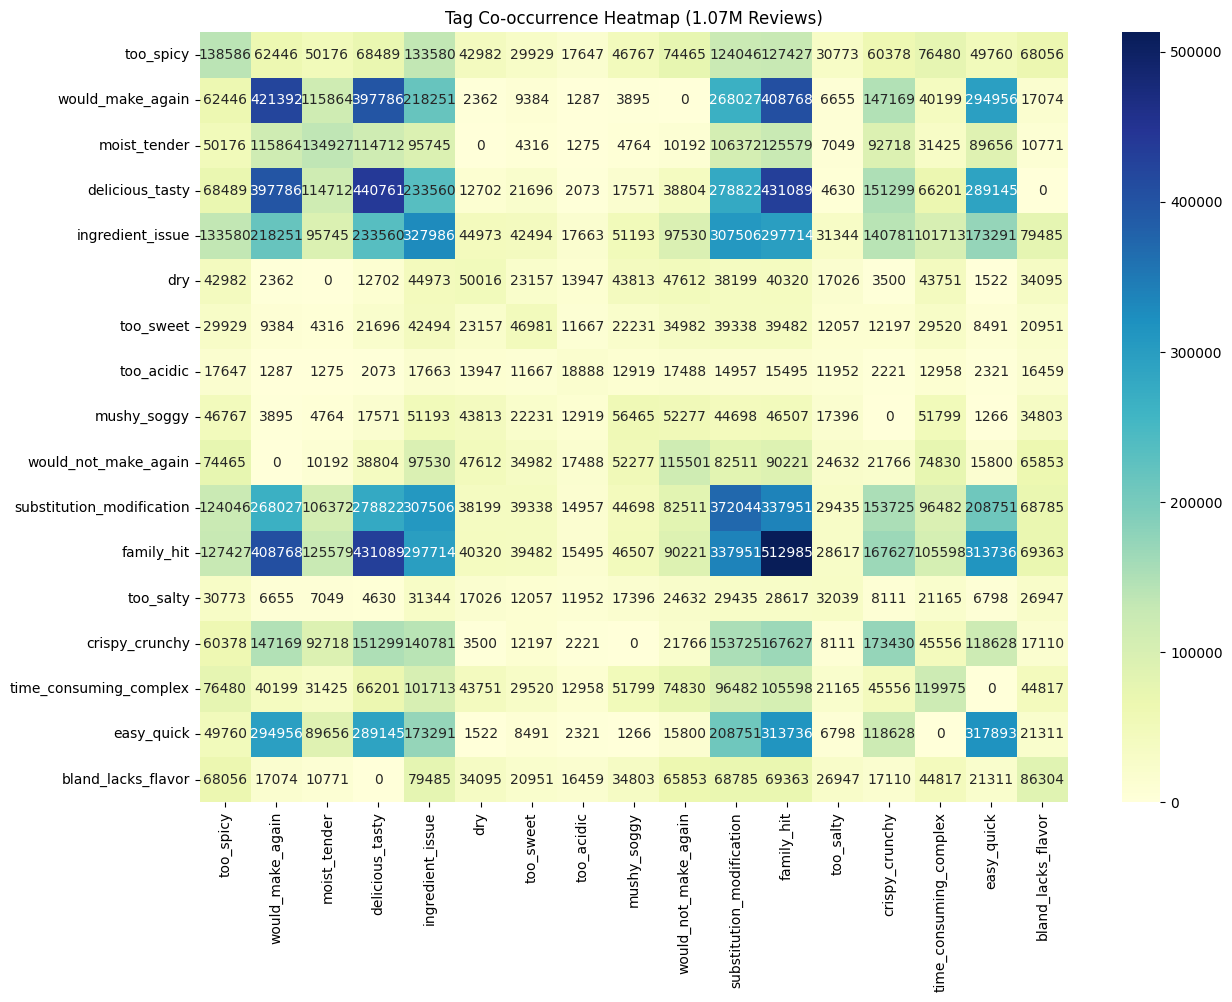

In [62]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pyspark.sql import functions as F

# 1. Identify prediction columns
pred_cols = [c for c in pruned_df.columns if c.startswith("pred_")]
tag_names = [c.replace("pred_", "") for c in pred_cols]
n = len(pred_cols)

# 2. Initialize the matrix with zeros
# FIX: Use underscore instead of hyphen to avoid Pylance error
co_occurrence_matrix = pd.DataFrame(0, index=tag_names, columns=tag_names)

print(f"Calculating co-occurrence for {n} tags...")

for i in range(n):
    for j in range(i, n):  # Start from i to calculate only the upper triangle
        tag_a = pred_cols[i]
        tag_b = pred_cols[j]
        
        # Count overlapping hits
        count = pruned_df.filter((F.col(tag_a) == 1) & (F.col(tag_b) == 1)).count()
        
        # Fill both sides of the diagonal
        co_occurrence_matrix.iloc[i, j] = count
        co_occurrence_matrix.iloc[j, i] = count

# 3. Plot Heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(co_occurrence_matrix, annot=True, cmap="YlGnBu", fmt="d")
plt.title("Tag Co-occurrence Heatmap (1.07M Reviews)")
plt.show()

In [65]:
# 1. Reuse your centroids and thresholds from memory
local_centroids = {row['tag']: row['centroid'] for row in centroids_df.collect()}
tags = list(thresholds.keys())

# 2. Build the similarity and prediction expressions
labeled_sim_exprs = [
    _native_cosine_sim(vector_to_array(F.col("features")), F.lit(local_centroids[tag])).alias(f"sim_{tag}")
    for tag in tags
]

labeled_pred_exprs = [
    (F.col(f"sim_{tag}") >= F.lit(thresholds[tag])).cast("int").alias(f"pred_{tag}")
    for tag in tags
]

# 3. Apply to the 40k labeled set
df_embed_bench = df_embed.select("*", *labeled_sim_exprs).select("*", *labeled_pred_exprs)

print(f"✅ df_embed_bench ready for benchmarking (N={df_embed_bench.count():,})")

✅ df_embed_bench ready for benchmarking (N=38,946)


In [66]:
# Apply your Semantic Pruning Logic to the benchmark set
negation_pairs = [
    ("would_make_again", "would_not_make_again"),
    ("delicious_tasty", "bland_lacks_flavor"),
    ("moist_tender", "dry"),
    ("crispy_crunchy", "mushy_soggy"),
    ("easy_quick", "time_consuming_complex")
]

for pos, neg in negation_pairs:
    s_pos, s_neg = f"sim_{pos}", f"sim_{neg}"
    p_pos, p_neg = f"pred_{pos}", f"pred_{neg}"
    
    df_embed_bench = df_embed_bench.withColumn(
        p_pos, F.when((F.col(p_pos) == 1) & (F.col(p_neg) == 1) & (F.col(s_pos) <= F.col(s_neg)), 0).otherwise(F.col(p_pos))
    ).withColumn(
        p_neg, F.when((F.col(p_pos) == 1) & (F.col(p_neg) == 1) & (F.col(s_neg) < F.col(s_pos)), 0).otherwise(F.col(p_neg))
    )

# Run Benchmarking
print(f"--- Model Benchmarking vs Transformer (v5 | N=38,946) ---")
print(f"{'Tag Name':<25} | {'Precision':<10} | {'Recall':<10} | {'F1-Score':<10}")
print("-" * 65)

results = []
for tag in tags:
    tp = df_embed_bench.filter((F.col(f"y_{tag}") == 1) & (F.col(f"pred_{tag}") == 1)).count()
    fp = df_embed_bench.filter((F.col(f"y_{tag}") == 0) & (F.col(f"pred_{tag}") == 1)).count()
    fn = df_embed_bench.filter((F.col(f"y_{tag}") == 1) & (F.col(f"pred_{tag}") == 0)).count()
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    results.append((tag, precision, recall, f1))
    print(f"{tag:<25} | {precision:<10.4f} | {recall:<10.4f} | {f1:<10.4f}")

avg_f1 = sum(r[3] for r in results) / len(results)
print(f"\n✅ Macro-Average F1 Score: {avg_f1:.4f}")

--- Model Benchmarking vs Transformer (v5 | N=38,946) ---
Tag Name                  | Precision  | Recall     | F1-Score  
-----------------------------------------------------------------


too_spicy                 | 0.0099     | 0.5604     | 0.0194    


would_make_again          | 0.8256     | 0.4556     | 0.5872    


moist_tender              | 0.1201     | 0.5342     | 0.1961    


delicious_tasty           | 0.8526     | 0.4756     | 0.6106    


...

too_salty                 | 0.0508     | 0.5686     | 0.0932    


crispy_crunchy            | 0.0459     | 0.5164     | 0.0844    


time_consuming_complex    | 0.1357     | 0.5434     | 0.2171    


easy_quick                | 0.4403     | 0.4537     | 0.4469    


bland_lacks_flavor        | 0.2257     | 0.5126     | 0.3134    

✅ Macro-Average F1 Score: 0.2713


In [69]:
# Test a hardened threshold for one sinkhole tag
test_tag = "too_spicy"
hard_threshold = 0.84

tp_hard = df_embed_bench.filter((F.col(f"y_{test_tag}") == 1) & (F.col(f"sim_{test_tag}") >= hard_threshold)).count()
fp_hard = df_embed_bench.filter((F.col(f"y_{test_tag}") == 0) & (F.col(f"sim_{test_tag}") >= hard_threshold)).count()

new_precision = tp_hard / (tp_hard + fp_hard) if (tp_hard + fp_hard) > 0 else 0
print(f"Hardened Precision for {test_tag} (Threshold {hard_threshold}): {new_precision:.4f}")

Hardened Precision for too_spicy (Threshold 0.84): 0.0380


In [70]:
def find_optimal_thresholds(df, tags, target_precision=0.50):
    optimized_map = {}
    print(f"{'Tag':<25} | {'Best Thresh':<12} | {'Precision':<10} | {'Recall':<10}")
    print("-" * 65)
    
    for tag in tags:
        best_f1 = 0
        best_thresh = 0.60
        final_p, final_r = 0, 0
        
        # Sweep from 0.60 to 0.95 in small increments
        for t in [x/100.0 for x in range(60, 96)]:
            tp = df.filter((F.col(f"y_{tag}") == 1) & (F.col(f"sim_{tag}") >= t)).count()
            fp = df.filter((F.col(f"y_{tag}") == 0) & (F.col(f"sim_{tag}") >= t)).count()
            fn = df.filter((F.col(f"y_{tag}") == 1) & (F.col(f"sim_{tag}") < t)).count()
            
            p = tp / (tp + fp) if (tp + fp) > 0 else 0
            r = tp / (tp + fn) if (tp + fn) > 0 else 0
            
            # Target a balance, but prioritize Precision for your project
            if p >= target_precision and r > 0.01: 
                best_thresh = t
                final_p, final_r = p, r
                break # Stop at the first threshold that hits our precision goal
        
        optimized_map[tag] = best_thresh
        print(f"{tag:<25} | {best_thresh:<12.2f} | {final_p:<10.4f} | {final_r:<10.4f}")
    
    return optimized_map

# Run the sweep on your 40k labeled benchmark set
optimal_thresholds = find_optimal_thresholds(df_embed_bench, tags)

Tag                       | Best Thresh  | Precision  | Recall    
-----------------------------------------------------------------


too_spicy                 | 0.60         | 0.0000     | 0.0000    


would_make_again          | 0.60         | 0.7696     | 0.7159    


moist_tender              | 0.60         | 0.0000     | 0.0000    


delicious_tasty           | 0.60         | 0.7956     | 0.7185    


...

too_salty                 | 0.60         | 0.0000     | 0.0000    


crispy_crunchy            | 0.60         | 0.0000     | 0.0000    


time_consuming_complex    | 0.60         | 0.0000     | 0.0000    


easy_quick                | 0.76         | 0.5142     | 0.1032    


bland_lacks_flavor        | 0.84         | 0.5188     | 0.0472    
